# 020. Spam Filtering - Logistic Regression

## Logistic Regression을 이용한 Binary Classification

- https://www.kaggle.com/uciml/sms-spam-collection-dataset
- SMS 스팸 컬렉션은 태그가 지정된 SMS 메시지 집합입니다. 여기에는 5,574개 메시지 중 영어로 된 SMS 메시지 한 세트가 포함되어 있으며 이에 따라 햄(합법적) 또는 스팸으로 태그가 지정됩니다.

필요한 라이브러리를 import 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

---
## 1. 데이터 로드 및 전처리

In [2]:
sms = pd.read_csv("datasets/spam.csv",
                  encoding="ISO-8859-1",
                  usecols=[0, 1], skiprows=1,
                  names=["label", "message"])
sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# 라벨을 숫자로 변환: ham → 0, spam → 1
sms.label = sms.label.map({"ham": 0, "spam": 1})

print(sms.label.value_counts())
print(f"\n스팸 비율: {sms.label.mean():.1%}")

label
0    4825
1     747
Name: count, dtype: int64

스팸 비율: 13.4%


---
## 2. Train / Test Split (8:2)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    sms.message, sms.label, test_size=0.2, random_state=42
)
print(f"훈련: {X_train.shape[0]}개, 테스트: {X_test.shape[0]}개")

훈련: 4457개, 테스트: 1115개


---
## 3. CountVectorizer를 이용한 문장 벡터화

텍스트를 단어 빈도(Bag of Words) 행렬로 변환합니다.

In [5]:
couvec = CountVectorizer()

# 훈련 데이터로 단어 사전 학습 + 변환
X_train_vec = couvec.fit_transform(X_train)

# 테스트 데이터는 동일한 단어 사전으로 변환만 수행
X_test_vec = couvec.transform(X_test)

print(f"단어 사전 크기: {len(couvec.get_feature_names_out())}개")
print(f"훈련 행렬: {X_train_vec.shape}")
print(f"테스트 행렬: {X_test_vec.shape}")

단어 사전 크기: 7735개
훈련 행렬: (4457, 7735)
테스트 행렬: (1115, 7735)


In [6]:
# Bag of Words 행렬 확인 (일부)
feature_names = couvec.get_feature_names_out()
df_bow = pd.DataFrame(
    X_train_vec[:5].toarray(),
    columns=feature_names
)
# 값이 0이 아닌 컬럼만 표시
nonzero_cols = df_bow.columns[df_bow.sum() > 0]
df_bow[nonzero_cols]

,00,04,07973788240,08715203649,10,2003,300,31,40533,800,...,strong,symbol,that,the,they,to,un,up,yo,your
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,0,0,...,1,1,1,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,1,0,0,1


---
## 4. 모델 학습 및 예측

In [7]:
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### predict() vs predict_proba()

- `predict()` — threshold 0.5 기준으로 클래스(0 or 1) 반환
- `predict_proba()` — 각 클래스에 속할 확률을 반환

In [8]:
# 클래스 예측
y_pred = lr_classifier.predict(X_test_vec)

# 확률 예측
y_prob = lr_classifier.predict_proba(X_test_vec)

# 비교: 처음 5개 샘플
print("예측 클래스 | Ham 확률 | Spam 확률 | 실제")
print("-" * 45)
for i in range(5):
    print(f"    {y_pred[i]}      |  {y_prob[i][0]:.4f}  |  {y_prob[i][1]:.4f}   |  {y_test.iloc[i]}")

예측 클래스 | Ham 확률 | Spam 확률 | 실제
---------------------------------------------
    0      |  0.9906  |  0.0094   |  0
    0      |  0.9980  |  0.0020   |  0
    1      |  0.4464  |  0.5536   |  1
    0      |  0.9982  |  0.0018   |  0
    1      |  0.0049  |  0.9951   |  1


---
## 5. Model Evaluation

### Confusion Matrix

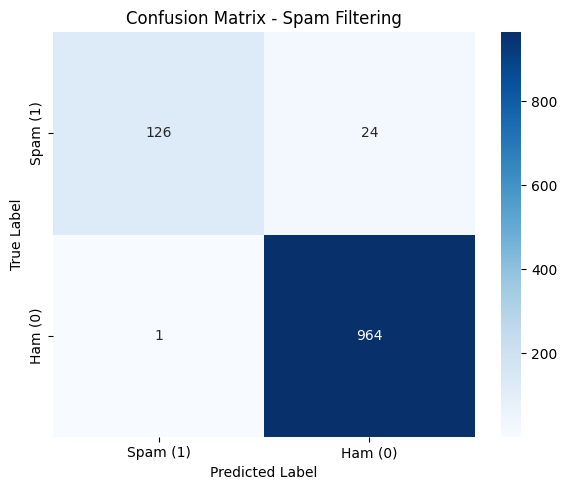

TP: 126 - 스팸을 스팸으로 정확히 예측
FN: 24 - 스팸을 햄으로 잘못 예측 (놓친 스팸)
FP: 1 - 햄을 스팸으로 잘못 예측 (오탐)
TN: 964 - 햄을 햄으로 정확히 예측


In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Spam (1)', 'Ham (0)'],
            yticklabels=['Spam (1)', 'Ham (0)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Spam Filtering')
plt.tight_layout()
plt.show()

# labels=[1, 0] 순서이므로:
# cm[0,0] = TP (Spam→Spam), cm[0,1] = FN (Spam→Ham)
# cm[1,0] = FP (Ham→Spam),  cm[1,1] = TN (Ham→Ham)
print(f"TP: {cm[0,0]} - 스팸을 스팸으로 정확히 예측")
print(f"FN: {cm[0,1]} - 스팸을 햄으로 잘못 예측 (놓친 스팸)")
print(f"FP: {cm[1,0]} - 햄을 스팸으로 잘못 예측 (오탐)")
print(f"TN: {cm[1,1]} - 햄을 햄으로 정확히 예측")

### Classification Report & F1 Score 

- accuracy — 가장 직관적인 지표로, 전체 중 맞춘 비율입니다.
- macro avg — Ham과 Spam 각각의 precision/recall/f1을 단순 평균한 값입니다. 두 클래스를 동등하게 취급합니다.
- weighted avg — 각 클래스의 샘플 수(support)에 비례하여 가중 평균한 값입니다.

In [11]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy:  0.9776
Precision: 0.9921
Recall:    0.8400
F1 Score:  0.9097

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.99      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### ROC Curve & AUC 

## ROC Curve란?

ROC(Receiver Operating Characteristic) Curve는 분류 모델의 **threshold(임계값)를 0에서 1까지 변화**시키면서, 각 지점에서의 TPR과 FPR을 그래프로 나타낸 것입니다.

| 축 | 지표 | 의미 |
|-----|------|------|
| Y축 | TPR (True Positive Rate) = Recall | 실제 스팸 중 스팸으로 탐지한 비율. **높을수록 좋음** |
| X축 | FPR (False Positive Rate) | 정상 메시지 중 스팸으로 잘못 판정한 비율. **낮을수록 좋음** |

## 그래프의 두 선

| 선 | 의미 |
|----|------|
| 파란 실선 (ROC curve) | 우리 모델의 성능. **좌상단에 가까울수록 좋은 모델** |
| 빨간 점선 (Random classifier) | 동전 던지기 수준의 랜덤 분류기 (대각선 = AUC 0.5) |

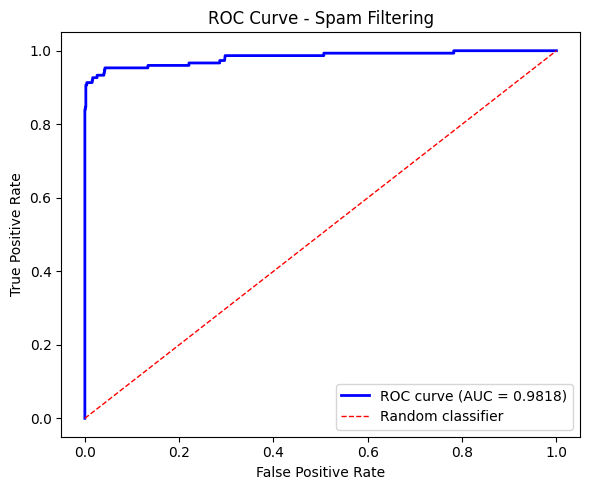

In [12]:
# Spam(1) 클래스의 확률을 사용하여 ROC curve 계산
y_prob_spam = y_prob[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_spam)
auc = roc_auc_score(y_test, y_prob_spam)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Spam Filtering')
plt.legend()
plt.tight_layout()
plt.show()

## AUC = 0.9818 해석

AUC(Area Under the Curve)는 ROC 곡선 아래의 면적입니다.

| AUC 범위 | 판정 | 이 모델 |
|----------|------|--------|
| 0.9 ~ 1.0 | 매우 우수 | ✅ **0.9818** |
| 0.8 ~ 0.9 | 우수 | |
| 0.7 ~ 0.8 | 보통 | |
| 0.5 ~ 0.7 | 미흡 | |
| 0.5 | 랜덤 (쓸모없음) | |

**AUC 0.9818의 의미**: 임의의 스팸 메시지와 정상 메시지를 하나씩 뽑았을 때, 모델이 스팸에 더 높은 확률을 부여할 확률이 **98.18%**입니다.